
Stats pour Set 1 (base):
Récompense moyenne: 34.23
Récompense max: 41.00

Grille avec chemin final:
S 1 2 . . X . . . . . . . . .
. X 3 . . . . . . . . . . . .
. . 4 R . . . . . . . . . . .
. . . 6 D . . . . . . . . . .
. . . 7 8 X . . . . . . . . .
. . . . 9 R 1 . . . . . . . .
. . . . . . 2 D . . . . . . .
. . . . . . 3 4 R . . . . . .
. . . . . . . . 6 X . . . . .
. . . . . . . . 7 . D . . . .
. . . . . . . . 8 9 R 1 . . .
. . . . . . . . . . . 2 D . .
. . . . R . . . . . . 3 . . .
. . . . . . . . . . . 4 . X .
. . . . . . . . . . . 5 6 7 B

Stats pour Set 2 (plus d'exploration):
Récompense moyenne: 34.76
Récompense max: 41.00

Stats pour Set 3 (apprentissage rapide):
Récompense moyenne: 39.52
Récompense max: 41.00


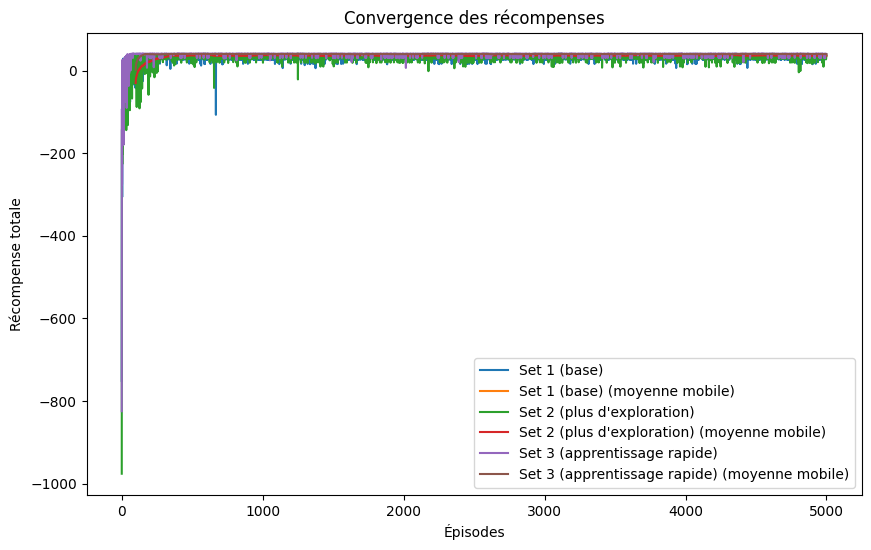

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

class ExplorerEnv:
    def __init__(self, grid_size=15):
        self.grid_size = grid_size
        self.start = (0, 0)
        self.base = (14, 14)

        self.resources = [(2, 3), (5, 5), (7, 8), (10, 10), (12, 4)]
        self.num_resources = len(self.resources)
        self.dangers = [(3, 4), (6, 7), (9, 10), (11, 12)]
        self.obstacles = [(1, 1), (4, 5), (8, 9), (13, 13), (0, 5)]
        self.movement_cost = -0.1
        self.resource_reward = 5
        self.danger_penalty = -10
        self.base_reward = 20
        self.max_states = self.grid_size ** 2 * (1 << self.num_resources)
        self.reset()

    def reset(self):
        self.position = self.start
        self.collected = set()
        return self.get_state()

    def get_state(self):
        pos_int = self.position[0] * self.grid_size + self.position[1]
        mask = 0
        for i, res in enumerate(self.resources):
            if res in self.collected:
                mask |= (1 << i)
        return pos_int * (1 << self.num_resources) + mask

    def step(self, action):

        deltas = [(0, -1), (0, 1), (-1, 0), (1, 0)]
        nr, nc = self.position[0] + deltas[action][0], self.position[1] + deltas[action][1]
        reward = self.movement_cost
        done = False


        if 0 <= nr < self.grid_size and 0 <= nc < self.grid_size and (nr, nc) not in self.obstacles:
            self.position = (nr, nc)


        pos = self.position
        if pos in self.dangers:
            reward += self.danger_penalty
        if pos in self.resources and pos not in self.collected:
            reward += self.resource_reward
            self.collected.add(pos)
        if pos == self.base:
            reward += self.base_reward
            done = True

        return self.get_state(), reward, done

def train_q_learning(env, alpha, gamma, epsilon, n_episodes=5000):
    Q = np.zeros((env.max_states, 4))
    rewards = []
    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        while True:
            if random.random() < epsilon:
                action = random.randint(0, 3)
            else:
                action = np.argmax(Q[state])
            next_state, reward, done = env.step(action)
            total_reward += reward
            Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
            state = next_state
            if done:
                break
        rewards.append(total_reward)
    return Q, rewards

def simulate_path(env, Q):
    state = env.reset()
    path = [env.position]
    while True:
        action = np.argmax(Q[state])
        next_state, _, done = env.step(action)
        path.append(env.position)
        state = next_state
        if done:
            break
    return path

def display_grid(env, path):
    grid = [['.' for _ in range(env.grid_size)] for _ in range(env.grid_size)]
    grid[env.start[0]][env.start[1]] = 'S'
    grid[env.base[0]][env.base[1]] = 'B'
    for r in env.resources:
        grid[r[0]][r[1]] = 'R'
    for d in env.dangers:
        grid[d[0]][d[1]] = 'D'
    for o in env.obstacles:
        grid[o[0]][o[1]] = 'X'
    for i, p in enumerate(path):
        if grid[p[0]][p[1]] == '.':
            grid[p[0]][p[1]] = str(i % 10)
    print("\nGrille avec chemin final:")
    for row in grid:
        print(' '.join(row))

def plot_convergence(rewards, label):
    plt.plot(rewards, label=label)

    if len(rewards) > 100:
        moving_avg = np.convolve(rewards, np.ones(100)/100, mode='valid')
        plt.plot(range(99, len(rewards)), moving_avg, label=f"{label} (moyenne mobile)")


env = ExplorerEnv()
params = [
    {"alpha": 0.1, "gamma": 0.99, "epsilon": 0.1, "label": "Set 1 (base)"},
    {"alpha": 0.05, "gamma": 0.95, "epsilon": 0.2, "label": "Set 2 (plus d'exploration)"},
    {"alpha": 0.2, "gamma": 0.9, "epsilon": 0.05, "label": "Set 3 (apprentissage rapide)"}
]

plt.figure(figsize=(10, 6))
for p in params:
    Q, rewards = train_q_learning(env, p["alpha"], p["gamma"], p["epsilon"])
    plot_convergence(rewards, p["label"])
    print(f"\nStats pour {p['label']}:")
    print(f"Récompense moyenne: {np.mean(rewards):.2f}")
    print(f"Récompense max: {np.max(rewards):.2f}")
    if p == params[0]:
        path = simulate_path(env, Q)
        display_grid(env, path)

plt.title("Convergence des récompenses")
plt.xlabel("Épisodes")
plt.ylabel("Récompense totale")
plt.legend()
plt.savefig("convergence.png")
plt.show()

In [ ]:
# apprend un comportement optimal en équilibrant exploration (pour collecter ressources) et exploitation (chemin court vers la base).
#  Avec gamma élevé, il valorise les récompenses futures